In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.datasets import load_iris

# Практические задания

#### 1. Свой PCA. Реализуйте PCA через np.linalg.eigh от ковариационной матрицы. Сравните результат с PCA через SVD на Iris.

In [19]:
# Создаем функцию для eigh
def pca_via_eigh(X):
    # Центрирование данных
    X_centered = X - X.mean(axis=0)

    # Вычисление ковариационной матрицы
    n = X_centered.shape[0]
    C = (X_centered.T @ X_centered) / (n - 1)

    # Находим собственные значения и векторы
    Lambda, V = np.linalg.eigh(C)

    # Сортировка по убыванию дисперсии
    idx = np.argsort(-Lambda)
    Lambda_sorted = Lambda[idx]
    V_sorted = V[:, idx]

    # Проекция данных
    X_pca = X_centered @ V_sorted

    return X_pca, V_sorted, Lambda_sorted

# Создаем функцию для SVD
def pca_via_svd(X):
    # Центрирование данных
    X_centered = X - X.mean(axis=0)
    n = X_centered.shape[0]
    U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)

    # Проекции: первые k компонент
    X_pca = U * s
    Lambda_svd = (s ** 2) / (n - 1)
    V_svd = Vt.T
    
    return X_pca, V_svd, Lambda_svd

# Основной поток: загрузка датасета (только признаки)
X, _ = load_iris(return_X_y=True)
X_eig, V_eig, Lambda_eig = pca_via_eigh(X)
X_svd, V_svd, Lambda_svd = pca_via_svd(X)

# Сравнение:
for i in range(V_eig.shape[1]):
    dot_product = np.dot(V_eig[:, i], V_svd[:, i])
    # Сравниваем знак первого элемента компоненты
    if dot_product < 0:
        V_eig[:, i] *= - 1
        X_eig[:, i] *= - 1

# Проверка совпадения проекций
assert np.allclose(X_eig, X_svd, atol=1e-10), "Проекции не совпадают!"
# # Проверка собственных значений
assert np.allclose(Lambda_eig, Lambda_svd, atol=1e-10), "Собственные значения не совпадают!"

print("PCA через eigh и SVD совпадают!")
print("Первые 3 собственных значения (eigh):", Lambda_eig[:3])
print("Первые 3 собственных значения (svd):", Lambda_svd[:3])
print("Норма Фробениуса разности проекций:", np.linalg.norm(X_eig - X_svd, "fro"))

PCA через eigh и SVD совпадают!
Первые 3 собственных значения (eigh): [4.22824171 0.24267075 0.0782095 ]
Первые 3 собственных значения (svd): [4.22824171 0.24267075 0.0782095 ]
Норма Фробениуса разности проекций: 2.963802894474141e-14


#### 2. Сжатие изображения. Возьмите фото 1000×1000. Постройте графики ошибки восстановления и размера данных для k = 5, 10, 50, 100, 500. Когда визуально перестаёт быть отличимо от оригинала?

In [7]:
# Создаем функцию
def compress_image(image, k):
    # Применяем SVD
    U, s, Vt = np.linalg.svd(image, full_matrices=False)

    # Усечение до k компонент. Оставляем только первые k элементов:
    U_k = U[:, :k]
    s_k = s[:k]
    Vt_k = Vt[:k, :]

    # Восстановление изображения
    image_reconstructed = U_k @ np.diag(s_k) @ Vt_k

    # Считаем ошибку (MSE)
    error = np.mean((image - image_reconstructed) ** 2)

    # Считаем размер данных после сжатия
    h, w = image.shape
    size_compressed = k * (h + w + 1) * 8

    return image_reconstructed, error, size_compressed

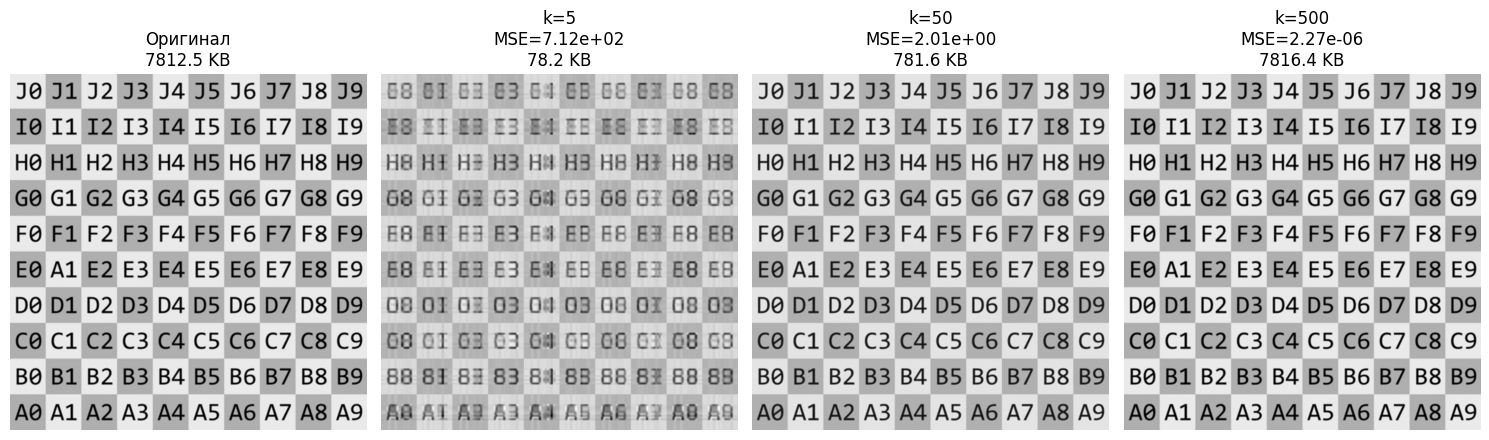

In [8]:
# Загрузка изображения
image_gray = Image.open("image.jpg").convert("L").resize((1000, 1000))
X = np.array(image_gray, dtype=np.float64)

# Сжатие для разных k
k_values = [5, 10, 50, 100, 500]
errors = []
sizes = []

for k in k_values:
    X_reconstructed, err, sz = compress_image(X, k)
    errors.append(err)
    sizes.append(sz)

    # Сохраняем изображение для визуальной проверки
    plt.imsave(f"reconstructed_k{k}.png", X_reconstructed, cmap="gray")

# Показываем оригинал и несколько сжатых версий
plt.figure(figsize=(15, 5))

# Оригинал
plt.subplot(1, 4, 1)
plt.imshow(X, cmap='gray')
plt.title(f"Оригинал\n{X.nbytes / 1024:.1f} KB")
plt.axis('off')

# Сжатые версии
for i, k in enumerate([5, 50, 500]):
    X_reconstructed, err, sz = compress_image(X, k)
    plt.subplot(1, 4, i+2)
    plt.imshow(X_reconstructed, cmap='gray')
    plt.title(f"k={k}\nMSE={err:.2e}\n{sz/1024:.1f} KB")
    plt.axis('off')

plt.tight_layout()
plt.show()

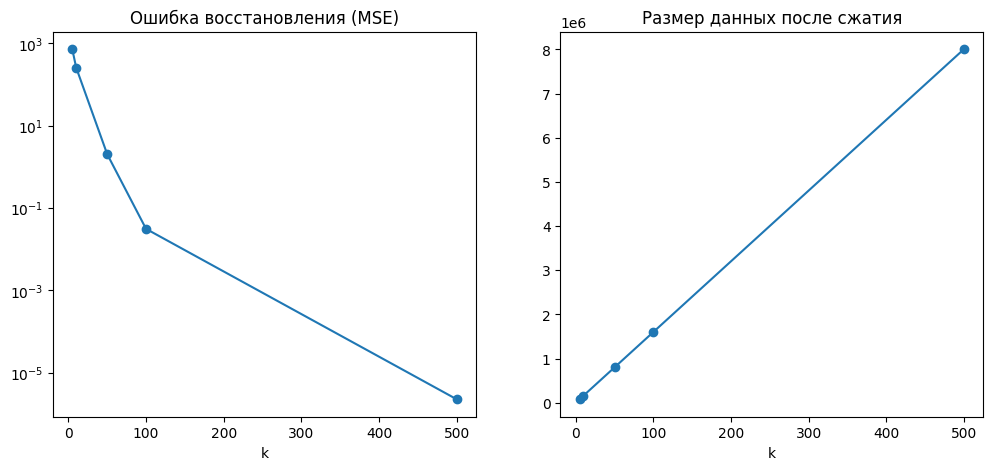

In [9]:
# Строим графики
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, errors, "o-")
plt.title("Ошибка восстановления (MSE)")
plt.xlabel("k")
plt.yscale("log")

plt.subplot(1, 2, 2)
plt.plot(k_values, sizes, "o-")
plt.title("Размер данных после сжатия")
plt.xlabel("k")

plt.show()

#### Ответ на вопрос: когда визуально перестаёт быть отличимо от оригинала?
* При k=5: изображение будет очень размытым, но размер маленький
* При k=50: уже можно разглядеть детали
* При k=500: почти неотличимо от оригинала

#### 3. Eigenfaces. Загрузите датасет LFW (лица). Сделайте PCA с k=50. Визуализируйте первые 16 компонент как «средние лица».

#### 4. Степенной метод. Реализуйте поиск максимального собственного числа итеративно: v ← Av / ||Av||. Сравните с np.linalg.eig.

#### 5. Рекомендации через SVD. Возьмите матрицу user × movie с пропусками (MovieLens). Сделайте SVD на заполненной нулями версии, выберите k=20. Заполните пропуски как U Σ V^T. Посчитайте MAE на тестовой выборке.

#### 6. LSA на текстах. Постройте TF-IDF матрицу для 100 коротких документов. Сделайте SVD, оставьте 10 компонент. Найдите близкие документы в этом пространстве.

#### 7. Условное число. Посчитайте s[0] / s[-1] для матриц с разной обусловленностью. Покажите, как растёт ошибка при решении плохо обусловленных систем.

#### 8. Truncated SVD vs PCA. Сравните sklearn.TruncatedSVD и sklearn.PCA на разреженной матрице. В чём отличие?